# AlexNet ECG Classification — Local (M3 Pro)
**Dataset:** PTB-XL — multi-label ECG classification (MI, STTC, CD, HYP)  
**Device:** Apple Silicon MPS

## 1. Install Dependencies (run once)

In [1]:
# # Run once if not installed:
# !pip install pyts opencv-python scikit-learn torch torchvision

## 2. Configuration

In [1]:
import os

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR      = '/home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG'
PKL_DIR       = BASE_DIR
PREPROC_DIR   = os.path.join(BASE_DIR, 'preprocessed')
MODEL_SAVE_DIR = os.path.join(BASE_DIR, 'models')

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── HYPERPARAMETERS ───────────────────────────────────────────────────────────
EPOCHS        = 100
# !! AlexNetAttention self-attention builds a (B, 3844, 3844) energy matrix at conv1.
#    Memory cost = B × 3844² × 4 bytes  →  batch=128 needs 7.6 GB for that tensor ALONE.
#    Repo default is 4. Use 4–8 for AlexNetAttention; 128 is fine for plain AlexNet.
BATCH_SIZE    = 16      # repo default; safe for AlexNetAttention on MPS
LEARNING_RATE = 0.01
OPTIMIZER     = 'sgd'  # repo uses plain SGD, no momentum
L2_DECAY      = 0.0
NB_FILTERS    = 8
N_CLASSES     = 4
PATIENCE      = 20
SEED          = 42

# AlexNet uses Dropout2d(0.3); AlexNetAttention uses Dropout2d(0) — both hardcoded in models
USE_ATTENTION = True   # True → AlexNetAttention (paper's best model); False → plain AlexNet
MODEL_NAME    = 'alexnet_attention' if USE_ATTENTION else 'alexnet'

SPLIT_SIZES = [17111, 2156, 2163]

print(f'Config OK. Model: {MODEL_NAME} | Batch size: {BATCH_SIZE}')

Config OK. Model: alexnet_attention | Batch size: 16


## 3. Imports

In [2]:
import random
import pickle
import statistics
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, sosfilt
from pyts.image import GramianAngularField
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import roc_auc_score, roc_curve

# Device — MPS for Apple Silicon
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: cuda


## 4. Reproducibility

In [3]:
def configure_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

configure_seed(SEED)

## 5. Signal → Image Transformation Functions
Each 1D ECG lead is converted into 3 images: **GAF**, **MTF**, **RP**  
3 leads (I, II, V2) × 3 images = **9-channel input** to AlexNet

In [4]:
def ecgnorm(ecg):
    mn = ecg.min()
    rng = (ecg - mn).max()
    if rng == 0:
        return ecg - mn
    return (ecg - mn) / rng

def recurrence_plot(s, eps=0.1, steps=10):
    d = pairwise_distances(s[:, None])
    d = d / eps
    d[d > steps] = steps
    return d / 5.0 - 1   # maps [0,10] → [-1,1]

def get_quantiles(min_value=0, max_val=1, k=10):
    c = (max_val - min_value) / k
    b = min_value + c
    d = []
    for i in range(1, k):
        d.append(b)
        b += c
    d.append(max_val)
    return d

_quantiles = get_quantiles()

def value_to_quantile(x):
    for i, k in enumerate(_quantiles):
        if x <= k:
            return i
    return len(_quantiles) - 1   # fix: out-of-range → last bin, not bin 0

def get_mtf(x, size=10):
    q = np.vectorize(value_to_quantile)(x)
    r = np.zeros((q.shape[0], q.shape[0]))
    y = np.zeros((size, size))
    for i in range(x.shape[0] - 1):
        y[q[i], q[i + 1]] += 1
    row_sums = y.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    y = y / row_sums
    for i in range(r.shape[0]):
        for j in range(r.shape[1]):
            r[i, j] = y[q[i], q[j]]
    return r * 2 - 1   # fix: maps probabilities [0,1] → [-1,1], consistent with GAF and RP

def ecgtoimagetransf(ecg):
    aux_img = np.zeros((3, len(ecg), len(ecg)))
    gaf = GramianAngularField(image_size=len(ecg), method='summation')
    x_gaf = gaf.fit_transform(ecg.reshape(1, -1))
    mtf = get_mtf(ecg)
    rp  = recurrence_plot(ecg, steps=10)
    aux_img[0] = (x_gaf + 1) / 2      # GAF: [-1,1] → [0,1]
    aux_img[1] = (mtf + 1) / 2        # MTF: [-1,1] → [0,1]  (fix: was mtf+1 giving [0,0.2])
    aux_img[2] = (rp + 1) / 2         # RP:  [-1,1] → [0,1]
    return aux_img

def resize_channels(X_aux, size=256):
    output = []
    for z in range(X_aux.shape[0]):
        resized = cv2.resize(X_aux[z], (size, size))
        output.append(resized)
    return np.asarray(output)

band_pass_filter = butter(2, [1, 45], 'bandpass', fs=100, output='sos')

def ecg_to_image(ecg_sample):
    lead_I  = sosfilt(band_pass_filter, ecg_sample[:, 0])
    lead_II = sosfilt(band_pass_filter, ecg_sample[:, 1])
    lead_V2 = sosfilt(band_pass_filter, ecg_sample[:, 7])
    lead_I  = ecgnorm(lead_I)
    lead_II = ecgnorm(lead_II)
    lead_V2 = ecgnorm(lead_V2)
    X_aux = np.zeros((9, 1000, 1000))
    X_aux[0:3] = ecgtoimagetransf(lead_I)
    X_aux[3:6] = ecgtoimagetransf(lead_II)
    X_aux[6:9] = ecgtoimagetransf(lead_V2)
    X_aux = resize_channels(X_aux, size=256)
    X_aux = (X_aux * 255.0).astype('uint8')
    return X_aux

print('Signal transformation functions loaded.')

Signal transformation functions loaded.


## 6. Preprocess & Save (Run Once)
> **Skip if `preprocessed/` already has files.**

In [5]:
import shutil

def preprocess_partition(pkl_dir, save_dir, partition, force=False):
    x_dir = os.path.join(save_dir, f'X_cnn_{partition}')
    y_dir = os.path.join(save_dir, f'labels_{partition}')

    # if force:
    #     # Wipe and re-create the image directories so stale files don't persist
    #     for d in [x_dir, y_dir]:
    #         if os.path.exists(d):
    #             shutil.rmtree(d)
    os.makedirs(x_dir, exist_ok=True)
    os.makedirs(y_dir, exist_ok=True)

    with open(os.path.join(pkl_dir, f'X_{partition}_processed.pickle'), 'rb') as f:
        X = np.array(pickle.load(f))
    with open(os.path.join(pkl_dir, f'y_{partition}_processed.pickle'), 'rb') as f:
        y = np.array(pickle.load(f))

    n = X.shape[0]
    print(f'[{partition}] Processing {n} samples...')
    for i in range(n):
        x_out = os.path.join(x_dir, f'{i}.npy')
        y_out = os.path.join(y_dir, f'{i}.npy')
        if os.path.exists(x_out) and os.path.exists(y_out):
            continue
        np.save(x_out, ecg_to_image(X[i]))
        np.save(y_out, y[i])
        if (i + 1) % 500 == 0 or i == n - 1:
            print(f'  [{partition}] {i+1}/{n}', flush=True)
    print(f'[{partition}] Done.')

# Run with force=True to delete old (buggy MTF) images and regenerate correctly.
for part in ['train', 'dev', 'test']:
    preprocess_partition(PKL_DIR, PREPROC_DIR, part, force=False)

[train] Processing 17111 samples...
[train] Done.
[dev] Processing 2156 samples...
[dev] Done.
[test] Processing 2163 samples...
[test] Done.


## 7. Dataset & DataLoader

In [6]:
class ECGImageDataset(Dataset):
    def __init__(self, preproc_dir, split_sizes, part='train'):
        self.x_dir = os.path.join(preproc_dir, f'X_cnn_{part}')
        self.y_dir = os.path.join(preproc_dir, f'labels_{part}')
        part_map   = {'train': 0, 'dev': 1, 'test': 2}
        self.n     = split_sizes[part_map[part]]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        img   = np.load(os.path.join(self.x_dir, f'{idx}.npy')).astype('float32') / 255.0
        label = np.load(os.path.join(self.y_dir, f'{idx}.npy')).astype('float32')
        return torch.from_numpy(img), torch.from_numpy(label)

train_dataset = ECGImageDataset(PREPROC_DIR, SPLIT_SIZES, 'train')
dev_dataset   = ECGImageDataset(PREPROC_DIR, SPLIT_SIZES, 'dev')
test_dataset  = ECGImageDataset(PREPROC_DIR, SPLIT_SIZES, 'test')

# num_workers=0 and pin_memory=False required for MPS on Mac
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}')
x, y = next(iter(train_loader))
print(f'Batch X: {x.shape} | y: {y.shape}')

Train: 17111 | Dev: 2156 | Test: 2163
Batch X: torch.Size([16, 9, 256, 256]) | y: torch.Size([16, 4])


## 8. Model Definitions — AlexNet & AlexNetAttention

In [7]:
# ── Baseline AlexNet (matches alexnet.py in DL_ECG_Classification repo exactly) ─
class AlexNet(nn.Module):
    def __init__(self, n_classes, **kwargs):
        super().__init__()
        nb_filters = 8
        self.n_classes = n_classes
        self.conv2d_1 = nn.Conv2d(9, nb_filters, 11, stride=4)
        self.conv2d_2 = nn.Conv2d(nb_filters, nb_filters*2, 5, padding=2)
        self.conv2d_3 = nn.Conv2d(nb_filters*2, nb_filters*4, 3, padding=1)
        self.conv2d_4 = nn.Conv2d(nb_filters*4, nb_filters*8, 3, padding=1)
        self.conv2d_5 = nn.Conv2d(nb_filters*8, 256, 3, padding=1)
        self.linear_1 = nn.Linear(9216, 4096)
        self.linear_2 = nn.Linear(4096, 2048)
        self.linear_3 = nn.Linear(2048, n_classes)
        self.maxpool2d = nn.MaxPool2d(3, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout2d(0.3)

    def forward(self, X, **kwargs):
        x1 = self.relu(self.conv2d_1(X))
        maxpool1 = self.maxpool2d(x1)
        maxpool1 = self.dropout(maxpool1)
        x2 = self.relu(self.conv2d_2(maxpool1))
        maxpool2 = self.maxpool2d(x2)
        maxpool2 = self.dropout(maxpool2)
        x3 = self.relu(self.conv2d_3(maxpool2))
        x4 = self.relu(self.conv2d_4(x3))
        x5 = self.relu(self.conv2d_5(x4))
        x6 = self.maxpool2d(x5)
        x6 = self.dropout(x6)
        x6 = x6.reshape(x6.shape[0], -1)
        x7 = self.relu(self.linear_1(x6))
        x8 = self.relu(self.linear_2(x7))
        return self.linear_3(x8)


# ── Self-Attention block (matches alexnetattention.py exactly) ────────────────
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv   = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels,      kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, W, H = x.size()
        proj_query = self.query_conv(x).view(B, -1, W * H).permute(0, 2, 1)
        proj_key   = self.key_conv(x).view(B, -1, W * H)
        energy     = torch.bmm(proj_query, proj_key)
        attention  = torch.nn.functional.softmax(energy, dim=1)
        proj_value = self.value_conv(x).view(B, -1, W * H)
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(B, C, W, H)
        return self.gamma * out + x   # residual: starts as identity (gamma=0), learns to attend


# ── AlexNetAttention (matches alexnetattention.py exactly) ───────────────────
class AlexNetAttention(nn.Module):
    def __init__(self, n_classes=4, **kwargs):
        super().__init__()
        nb_filters = 8
        self.n_classes = n_classes
        self.conv2d_1   = nn.Conv2d(9, nb_filters, 11, stride=4)
        self.attention1 = SelfAttention(nb_filters)           # after conv1
        self.conv2d_2   = nn.Conv2d(nb_filters, nb_filters*2, 5, padding=2)
        self.conv2d_3   = nn.Conv2d(nb_filters*2, nb_filters*4, 3, padding=1)
        self.attention3 = SelfAttention(nb_filters*4)         # after conv3
        self.conv2d_4   = nn.Conv2d(nb_filters*4, nb_filters*8, 3, padding=1)
        self.conv2d_5   = nn.Conv2d(nb_filters*8, 256, 3, padding=1)
        self.linear_1   = nn.Linear(9216, 4096)
        self.linear_2   = nn.Linear(4096, 2048)
        self.linear_3   = nn.Linear(2048, n_classes)
        self.maxpool2d  = nn.MaxPool2d(3, stride=2)
        self.relu       = nn.ReLU()
        self.dropout    = nn.Dropout2d(0)   # no dropout in attention model

    def forward(self, X, **kwargs):
        x1 = self.relu(self.conv2d_1(X))
        x1 = self.attention1(x1)
        maxpool1 = self.maxpool2d(x1)
        maxpool1 = self.dropout(maxpool1)
        x2 = self.relu(self.conv2d_2(maxpool1))
        maxpool2 = self.maxpool2d(x2)
        maxpool2 = self.dropout(maxpool2)
        x3 = self.relu(self.conv2d_3(maxpool2))
        x3 = self.attention3(x3)
        x4 = self.relu(self.conv2d_4(x3))
        x5 = self.relu(self.conv2d_5(x4))
        x6 = self.maxpool2d(x5)
        x6 = self.dropout(x6)
        x6 = x6.view(x6.size(0), -1)
        x7 = self.relu(self.linear_1(x6))
        x8 = self.relu(self.linear_2(x7))
        return self.linear_3(x8)


# ── Instantiate chosen model ──────────────────────────────────────────────────
ModelClass = AlexNetAttention if USE_ATTENTION else AlexNet
model = ModelClass(N_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_NAME} | Trainable parameters: {total:,}')
print(model)

Model: alexnet_attention | Trainable parameters: 46,335,880
AlexNetAttention(
  (conv2d_1): Conv2d(9, 8, kernel_size=(11, 11), stride=(4, 4))
  (attention1): SelfAttention(
    (query_conv): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
    (key_conv): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
    (value_conv): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1))
  )
  (conv2d_2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2d_3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (attention3): SelfAttention(
    (query_conv): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
    (key_conv): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
    (value_conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (conv2d_4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2d_5): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (linear_1): Linear(in_features=9216, out_features=4096, bias=True)
  (

## 9. Loss, Optimizer & Helpers

In [8]:
class_weights = torch.tensor(
    [17111/4389, 17111/3136, 17111/1915, 17111/417], dtype=torch.float
).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

# Matches repo: plain SGD, no momentum
optim_map = {'sgd': torch.optim.SGD, 'adam': torch.optim.Adam}
optimizer = optim_map[OPTIMIZER](model.parameters(), lr=LEARNING_RATE, weight_decay=L2_DECAY)

# LR scheduler (not in paper, but helps — halves LR after 5 stagnant val-loss epochs)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'Criterion: BCEWithLogitsLoss | Optimizer: {OPTIMIZER} | LR: {LEARNING_RATE}')

Criterion: BCEWithLogitsLoss | Optimizer: sgd | LR: 0.01


In [9]:
def compute_scores(y_true, y_pred, matrix, norm_vec):
    for j in range(len(y_true)):
        gt, pr = y_true[j], y_pred[j]
        norm_gt   = not any(gt)   # all zeros → AD ground truth
        norm_pred = not any(pr)   # all zeros → AD prediction
        # per-disease TP/FN/FP/TN
        for i in range(N_CLASSES):
            if   gt[i] == 0 and pr[i] == 0: matrix[i, 3] += 1
            elif gt[i] == 1 and pr[i] == 0: matrix[i, 1] += 1
            elif gt[i] == 0 and pr[i] == 1: matrix[i, 2] += 1
            elif gt[i] == 1 and pr[i] == 1: matrix[i, 0] += 1
        # AD (implicit 5th class)
        if   norm_gt and     norm_pred: norm_vec[0] += 1  # TP
        elif norm_gt and not norm_pred: norm_vec[1] += 1  # FN
        elif not norm_gt and norm_pred: norm_vec[2] += 1  # FP
        else:                           norm_vec[3] += 1  # TN
    return matrix, norm_vec


def predict(model, X, threshold=None):
    logits = model(X)
    probs  = torch.sigmoid(logits).cpu().detach().numpy()
    if threshold is None:
        return probs
    return (probs > threshold).astype(float)


def compute_val_loss(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            losses.append(criterion(model(x_b), y_b).item())
    model.train()
    return statistics.mean(losses)


def threshold_optimization(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(DEVICE)
            all_probs.append(predict(model, x_b, threshold=None))
            all_labels.append(y_b.numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    thr    = np.zeros(N_CLASSES)
    for c in range(N_CLASSES):
        fpr, tpr, thresholds = roc_curve(labels[:, c], probs[:, c])
        gmean = np.sqrt(tpr * (1 - fpr))
        thr[c] = round(thresholds[np.argmax(gmean)], 2)
    model.train()
    return thr


def evaluate(model, loader, thr):
    model.eval()
    matrix   = np.zeros((N_CLASSES, 4))
    norm_vec  = np.zeros(4)   # [TP, FN, FP, TN] for AD class
    n_exact, n_total = 0, 0
    with torch.no_grad():
        for i, (x_b, y_b) in enumerate(loader):
            print(f'  eval {i+1}/{len(loader)}', end='\r')
            x_b = x_b.to(DEVICE)
            y_pred = predict(model, x_b, thr)
            y_true = y_b.numpy()
            matrix, norm_vec = compute_scores(y_true, y_pred, matrix, norm_vec)
            n_exact += int((y_true == y_pred).all(axis=1).sum())
            n_total += len(y_true)
    model.train()
    return matrix, norm_vec, n_exact, n_total


def eval_auroc(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(DEVICE)
            all_probs.append(predict(model, x_b, threshold=None))
            all_labels.append(y_b.numpy())
    model.train()
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    per_class = roc_auc_score(labels, probs, average=None)
    macro     = roc_auc_score(labels, probs, average='macro')
    micro     = roc_auc_score(labels, probs, average='micro')
    return per_class, macro, micro


def print_metrics(matrix, norm_vec, per_class_auroc, macro_auroc, micro_auroc,
                  n_exact=None, n_total=None, split='Test'):
    names = ['MI', 'STTC', 'CD', 'HYP']
    w = 72
    print(f'\n{"="*w}')
    print(f'{split} Results')
    print(f'{"="*w}')
    print(f'{"Class":<8} {"Sensitivity":>12} {"Specificity":>12} {"F1-score":>10} {"Accuracy":>10} {"AUROC":>8}')
    print(f'{"-"*w}')
    sens_list, spec_list, f1_list, acc_list = [], [], [], []
    for i, name in enumerate(names):
        tp, fn, fp, tn = matrix[i]
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        f1   = 2*tp / (2*tp + fp + fn + 1e-8)
        acc  = (tp + tn) / (tp + fn + fp + tn + 1e-8)
        sens_list.append(sens); spec_list.append(spec)
        f1_list.append(f1);     acc_list.append(acc)
        print(f'{name:<8} {sens:>12.4f} {spec:>12.4f} {f1:>10.4f} {acc:>10.4f} {per_class_auroc[i]:>8.4f}')
    # AD row
    tp, fn, fp, tn = norm_vec
    ad_sens = tp / (tp + fn + 1e-8)
    ad_spec = tn / (tn + fp + 1e-8)
    ad_f1   = 2*tp / (2*tp + fp + fn + 1e-8)
    ad_acc  = (tp + tn) / (tp + fn + fp + tn + 1e-8)
    print(f'{"AD":<8} {ad_sens:>12.4f} {ad_spec:>12.4f} {ad_f1:>10.4f} {ad_acc:>10.4f} {"N/A":>8}')
    print(f'{"-"*w}')
    # Macro includes AD (matches paper)
    all_sens = sens_list + [ad_sens]
    all_spec = spec_list + [ad_spec]
    all_f1   = f1_list   + [ad_f1]
    all_acc  = acc_list  + [ad_acc]
    print(f'{"Macro":<8} {np.mean(all_sens):>12.4f} {np.mean(all_spec):>12.4f} {np.mean(all_f1):>10.4f} {np.mean(all_acc):>10.4f} {macro_auroc:>8.4f}')
    tp_s = matrix[:,0].sum(); fn_s = matrix[:,1].sum()
    fp_s = matrix[:,2].sum(); tn_s = matrix[:,3].sum()
    micro_acc = (tp_s + tn_s) / (tp_s + fn_s + fp_s + tn_s + 1e-8)
    print(f'{"Micro":<8} {tp_s/(tp_s+fn_s+1e-8):>12.4f} {tn_s/(tn_s+fp_s+1e-8):>12.4f} {2*tp_s/(2*tp_s+fp_s+fn_s+1e-8):>10.4f} {micro_acc:>10.4f} {micro_auroc:>8.4f}')
    if n_exact is not None and n_total is not None:
        exact_acc = n_exact / n_total
        print(f'{"-"*w}')
        print(f'Exact match (subset) accuracy: {n_exact}/{n_total} = {exact_acc:.4f}')
    print(f'{"="*w}')

print('Helpers loaded.')

Helpers loaded.


## 10. Training Loop


--- Epoch 1/100 ---
  Train loss: 2.0530  |  Val loss: 1.9293  |  LR: 1.00e-02
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/alexnet_best_epoch1.pt

--- Epoch 2/100 ---
  Train loss: 1.7343  |  Val loss: 1.6875  |  LR: 1.00e-02
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/alexnet_best_epoch2.pt

--- Epoch 3/100 ---
  Train loss: 1.6868  |  Val loss: 1.6737  |  LR: 1.00e-02
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/alexnet_best_epoch3.pt

--- Epoch 4/100 ---
  Train loss: 1.6706  |  Val loss: 1.6636  |  LR: 1.00e-02
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/alexnet_best_epoch4.pt

--- Epoch 5/100 ---
  Train loss: 1.6481  |  Val loss: 1.6344  |  LR: 1.00e-02
  ** Best model saved -> /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/alexnet_best_epoch5.pt

--- Epoch 6/100 ---
  Train l

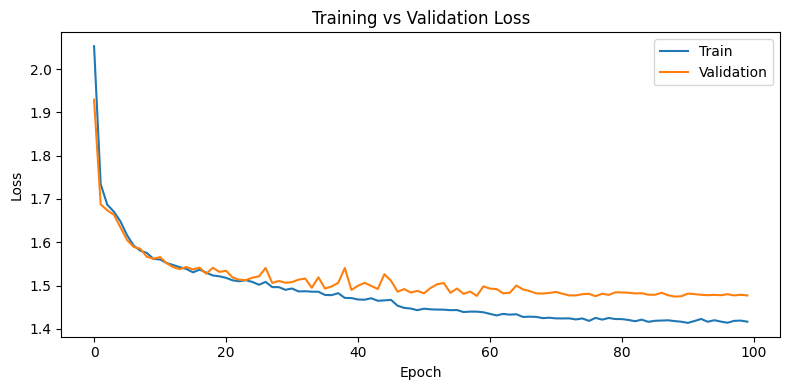

In [11]:
def plot_losses(train_losses, val_losses, save_path=None):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses,   label='Validation')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend(); plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f'Saved to {save_path}')
    plt.show()


train_mean_losses = []
valid_mean_losses = []
best_val_loss     = float('inf')
patience_count    = 0
best_epoch        = 0

model.train()

for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{EPOCHS} ---')
    batch_losses = []

    for i, (X_batch, y_batch) in enumerate(train_loader):
        print(f'  batch {i+1}/{len(train_loader)}', end='\r', flush=True)
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    mean_train = np.mean(batch_losses)
    mean_val   = compute_val_loss(model, dev_loader)
    train_mean_losses.append(mean_train)
    valid_mean_losses.append(mean_val)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Train loss: {mean_train:.4f}  |  Val loss: {mean_val:.4f}  |  LR: {current_lr:.2e}')

    scheduler.step(mean_val)  # reduce LR on plateau

    if mean_val < best_val_loss:
        best_val_loss  = mean_val
        best_epoch     = epoch
        patience_count = 0
        ckpt_path = os.path.join(MODEL_SAVE_DIR, f'{MODEL_NAME}_best_epoch{epoch}.pt')
        torch.save(model.state_dict(), ckpt_path)
        print(f'  ** Best model saved -> {ckpt_path}')
    else:
        patience_count += 1
        print(f'  No improvement. Patience: {patience_count}/{PATIENCE}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}. Best: {best_epoch}')
        break

plot_losses(train_mean_losses, valid_mean_losses,
            save_path=os.path.join(MODEL_SAVE_DIR, f'{MODEL_NAME}_loss_curve.png'))

## 11. Evaluation on Test Set

Set best epoch if model saved

In [ ]:
# best_epoch = 35

In [11]:
best_ckpt = os.path.join(MODEL_SAVE_DIR, f'{MODEL_NAME}_best_epoch{best_epoch}.pt')
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print(f'Loaded best model ({MODEL_NAME}) from epoch {best_epoch}')

print('\nOptimizing thresholds on validation set...')
thr = threshold_optimization(model, dev_loader)
print(f'Thresholds (MI, STTC, CD, HYP): {thr}')

print('\nEvaluating on test set...')
matrix, norm_vec, n_exact, n_total            = evaluate(model, test_loader, thr)
per_class_auroc, macro_auroc, micro_auroc     = eval_auroc(model, test_loader)
print_metrics(matrix, norm_vec, per_class_auroc, macro_auroc, micro_auroc,
              n_exact=n_exact, n_total=n_total, split='Test')

Loaded best model (alexnet_attention) from epoch 35

Optimizing thresholds on validation set...
Thresholds (MI, STTC, CD, HYP): [0.54 0.5  0.74 0.85]

Evaluating on test set...
  eval 136/136
Test Results
Class     Sensitivity  Specificity   F1-score   Accuracy    AUROC
------------------------------------------------------------------------
MI             0.7269       0.6925     0.5545     0.7013   0.7581
STTC           0.8489       0.7628     0.6549     0.7836   0.8804
CD             0.7048       0.8024     0.5959     0.7799   0.8339
HYP            0.6654       0.7558     0.3880     0.7448   0.7813
AD             0.7777       0.8120     0.7643     0.7975      N/A
------------------------------------------------------------------------
Macro          0.7448       0.7651     0.5915     0.7614   0.8134
Micro          0.7469       0.7539     0.5616     0.7524   0.7686
------------------------------------------------------------------------
Exact match (subset) accuracy: 859/2163 = 0.3971

## 12. Confusion Matrix

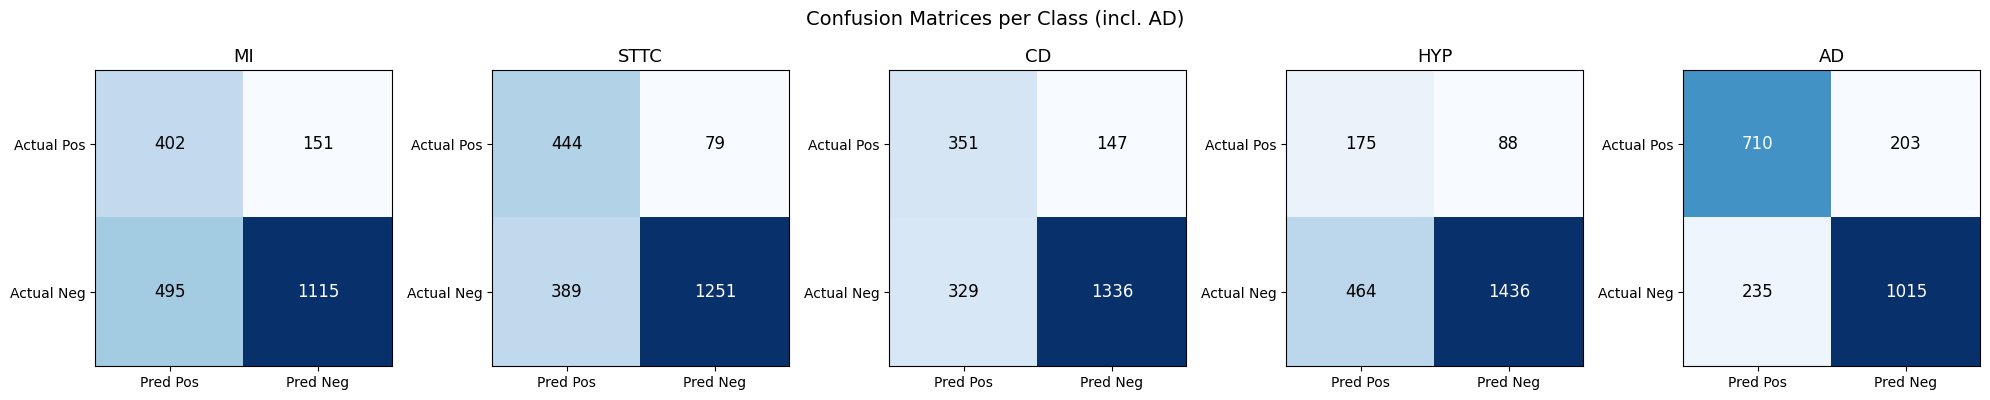

In [12]:
all_cms   = [matrix[i] for i in range(N_CLASSES)] + [norm_vec]
all_names = ['MI', 'STTC', 'CD', 'HYP', 'AD']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, name, counts in zip(axes, all_names, all_cms):
    tp, fn, fp, tn = counts
    cm = np.array([[int(tp), int(fn)], [int(fp), int(tn)]])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=13)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Pos', 'Pred Neg'])
    ax.set_yticklabels(['Actual Pos', 'Actual Neg'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha='center', va='center',
                    color='white' if cm[r, c] > cm.max()/2 else 'black', fontsize=12)

plt.suptitle('Confusion Matrices per Class (incl. AD)', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrices.png'))
plt.show()

## 13. Grad-CAM

In [14]:
CLASS_NAMES = ['MI', 'STTC', 'CD', 'HYP']

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = self.activations = None
        self._hooks = []
        self._hooks.append(model.conv2d_5.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())))
        self._hooks.append(model.conv2d_5.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())))

    def remove_hooks(self):
        for h in self._hooks: h.remove()

    def __call__(self, input_tensor, class_idx):
        self.model.eval()
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cv2.resize(cam, (256, 256))


def run_gradcam(model, sample_idx, partition='test', target_class=None, thr=None, alpha=0.5, save_path=None):
    img   = np.load(os.path.join(PREPROC_DIR, f'X_cnn_{partition}', f'{sample_idx}.npy')).astype('float32') / 255.0
    label = np.load(os.path.join(PREPROC_DIR, f'labels_{partition}', f'{sample_idx}.npy'))

    input_tensor = torch.from_numpy(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]

    # Threshold-based prediction (what the model actually outputs, incl. AD)
    if thr is not None:
        thr_pred   = (probs > thr).astype(int)
        is_ad_pred = not any(thr_pred)
        thr_label  = 'AD' if is_ad_pred else '+'.join(n for n, v in zip(CLASS_NAMES, thr_pred) if v)
    else:
        is_ad_pred = False
        thr_label  = None

    # GradCAM always needs a disease neuron — use argmax as proxy when AD is predicted
    if target_class is None:
        target_class = int(np.argmax(probs))

    gt_label = 'AD' if not any(label.astype(int)) else '+'.join(n for n, v in zip(CLASS_NAMES, label.astype(int)) if v)
    cam_note = ' (proxy — model predicts AD)' if is_ad_pred else ''
    print(f'Sample {sample_idx} | GT: {gt_label} | Pred: {thr_label} | GradCAM: {CLASS_NAMES[target_class]}{cam_note}')

    gradcam = GradCAM(model)
    heatmap = gradcam(input_tensor.requires_grad_(True), target_class)
    gradcam.remove_hooks()

    gt_str   = '  '.join([f'{n}={int(v)}' for n, v in zip(CLASS_NAMES, label)])
    pred_str = '  '.join([f'{n}={v:.3f}' for n, v in zip(CLASS_NAMES, probs)])
    cam_str  = f'{CLASS_NAMES[target_class]} (proxy — no AD neuron)' if is_ad_pred else CLASS_NAMES[target_class]
    title = (f'Grad-CAM | Sample {sample_idx}\n'
             f'GT:     {gt_str}  →  {gt_label}\n'
             f'Pred:   {pred_str}  →  {thr_label}\n'
             f'Target: {cam_str}')

    fig, axes = plt.subplots(3, 3, figsize=(12, 14))
    fig.suptitle(title, fontsize=10, family='monospace', y=0.97)
    fig.subplots_adjust(top=0.82, hspace=0.25, wspace=0.15)

    leads = ['Lead I', 'Lead II', 'Lead V2']
    transf = ['GAF', 'MTF', 'RP']
    for row in range(3):
        for col in range(3):
            ch = row * 3 + col
            base = (img[ch] * 255).astype(np.uint8)
            base_rgb = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)
            hm = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
            hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
            overlaid = cv2.addWeighted(base_rgb, 1 - alpha, hm, alpha, 0)
            axes[row][col].imshow(overlaid)
            axes[row][col].set_title(f'{leads[row]} — {transf[col]}', fontsize=9)
            axes[row][col].axis('off')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()


Sample 55 | GT: STTC | Pred: STTC | GradCAM: HYP
Saved to /home/dulat-rakhymkul/Documents/Temp/DataMining/PTB-XL-ECG/models/gradcam_sample0.png


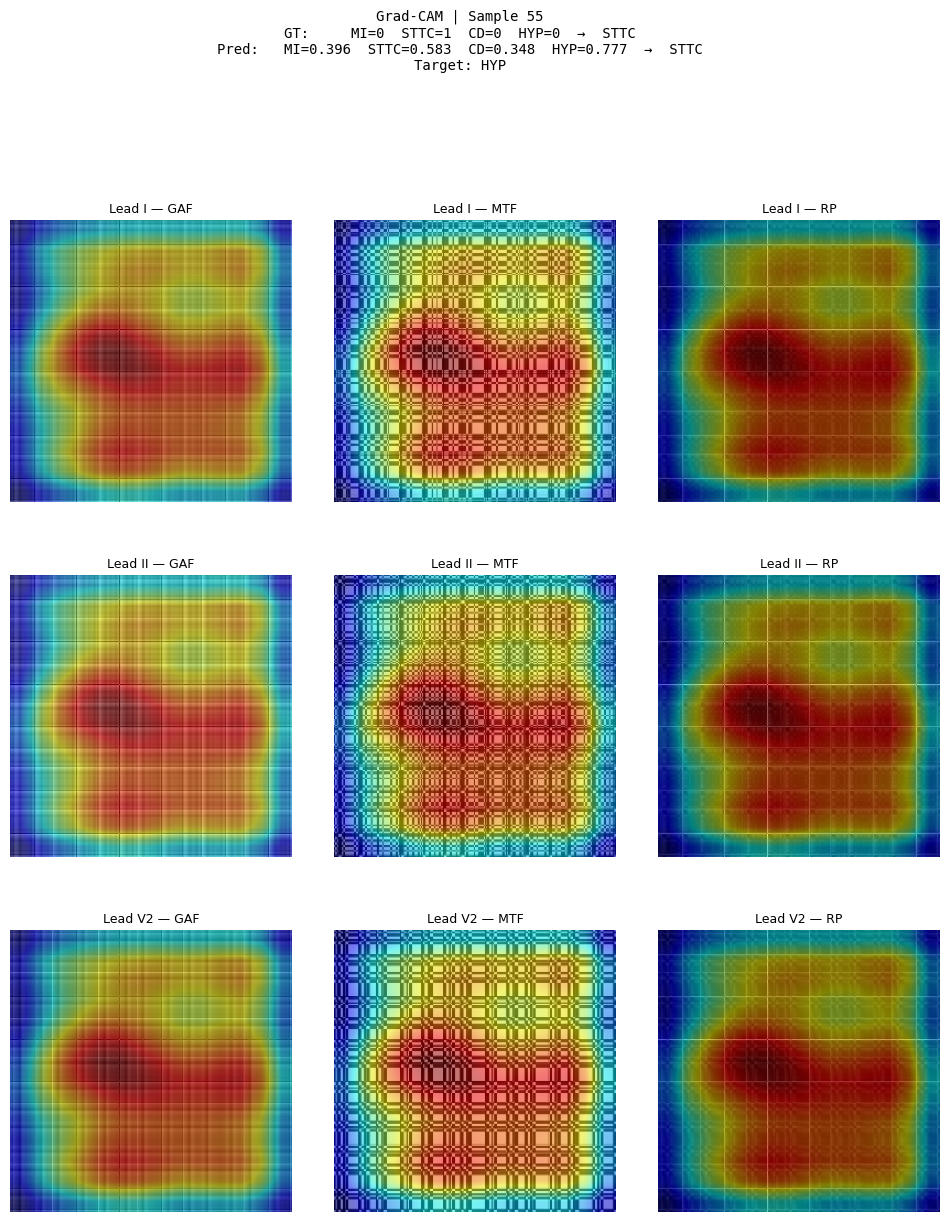

In [21]:
run_gradcam(model, sample_idx=55, partition='test', target_class=None, thr=thr,
            save_path=os.path.join(MODEL_SAVE_DIR, 'gradcam_sample0.png'))

## 14. Preprocessed Image Examples (GAF / MTF / RP)

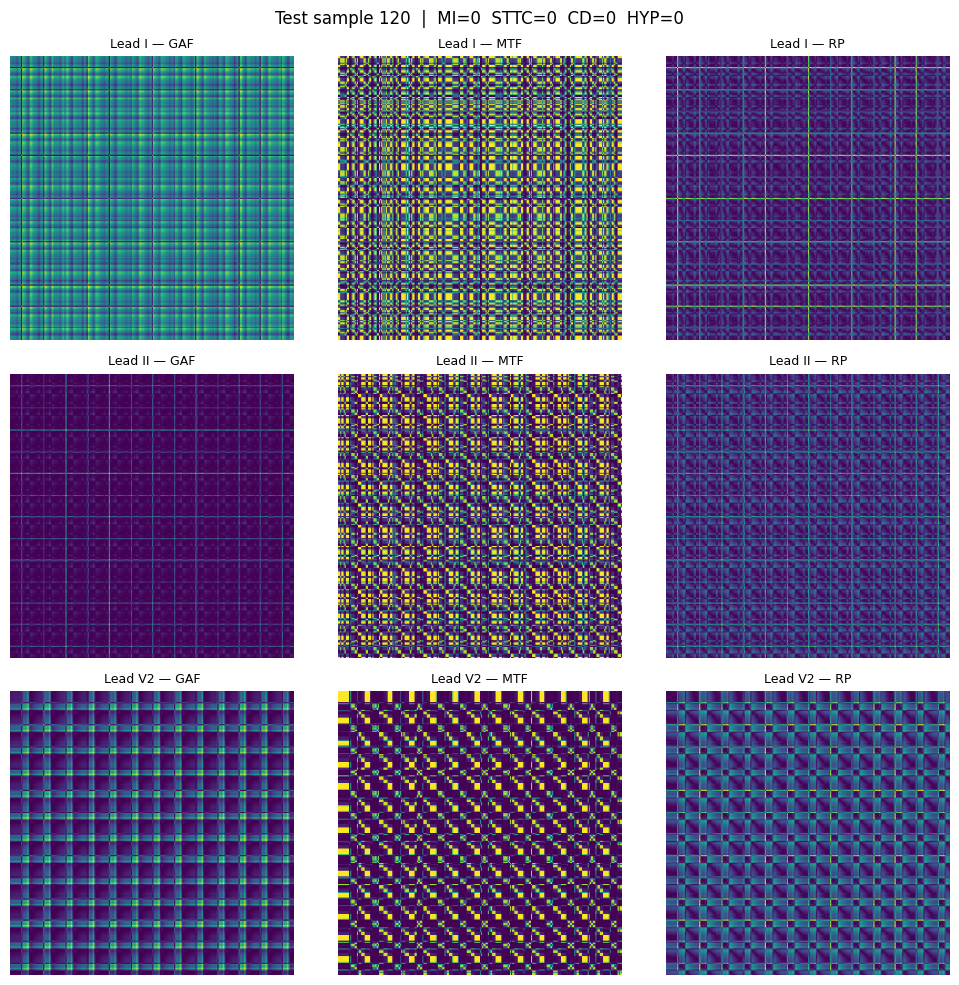

Saved sample_test_120.png


In [16]:
SAMPLE_INDICES = [120]   # change to see different samples
PARTITION      = 'test'      # 'train', 'dev', or 'test'

leads  = ['Lead I', 'Lead II', 'Lead V2']
transf = ['GAF',    'MTF',     'RP']

for idx in SAMPLE_INDICES:
    img   = np.load(os.path.join(PREPROC_DIR, f'X_cnn_{PARTITION}', f'{idx}.npy')).astype('float32') / 255.0
    label = np.load(os.path.join(PREPROC_DIR, f'labels_{PARTITION}', f'{idx}.npy'))
    label_str = '  '.join([f'{n}={int(v)}' for n, v in zip(['MI','STTC','CD','HYP'], label)])

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f'{PARTITION.capitalize()} sample {idx}  |  {label_str}', fontsize=12)

    for row in range(3):
        for col in range(3):
            ch = row * 3 + col
            axes[row][col].imshow(img[ch], cmap='viridis')
            axes[row][col].set_title(f'{leads[row]} — {transf[col]}', fontsize=9)
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, f'sample_{PARTITION}_{idx}.png'), dpi=150)
    plt.show()
    print(f'Saved sample_{PARTITION}_{idx}.png')